# Notebook 04 - Two-Tower Neural Recommendation Model

This notebook implements a two-tower (dual-encoder) neural architecture in PyTorch for restaurant recommendations.

**Architecture:**
- User Tower: [7 scalar features + 1024-dim category embedding] -> 256-dim user embedding
- Item Tower: [~30 scalar features + 1024-dim category embedding] -> 256-dim item embedding
- Loss: InfoNCE contrastive loss with in-batch negatives
- Similarity: Dot product

**Metrics:** Hit@K, NDCG@K, Precision@K, Recall@K for K = 5, 10, 20

## Setup

In [17]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
import os
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Load Data

In [19]:
DATA_DIR = "/content/drive/My Drive/rec_system"

# Load review interactions
train_reviews = pd.read_parquet(f"{DATA_DIR}/train_reviews.parquet")
val_reviews = pd.read_parquet(f"{DATA_DIR}/val_reviews.parquet")
test_reviews = pd.read_parquet(f"{DATA_DIR}/test_reviews.parquet")

# Load user and business features (scalars only)
users_df = pd.read_parquet(f"{DATA_DIR}/users.parquet")
businesses_df = pd.read_parquet(f"{DATA_DIR}/businesses.parquet")

# Load category embeddings
user_cat_emb = np.load(f"{DATA_DIR}/user_category_embeddings.npy")
business_cat_emb = np.load(f"{DATA_DIR}/business_category_embeddings.npy")

# Load embedding indices (maps row index to user_id/business_id)
user_emb_index = pd.read_parquet(f"{DATA_DIR}/user_embedding_index.parquet")
business_emb_index = pd.read_parquet(f"{DATA_DIR}/business_embedding_index.parquet")

print(f"Train: {len(train_reviews):,} interactions")
print(f"Val: {len(val_reviews):,} interactions")
print(f"Test: {len(test_reviews):,} interactions")
print(f"\nUsers: {len(users_df):,}")
print(f"Businesses: {len(businesses_df):,}")
print(f"\nUser embeddings shape: {user_cat_emb.shape}")
print(f"Business embeddings shape: {business_cat_emb.shape}")

Train: 1,918,257 interactions
Val: 153,250 interactions
Test: 153,746 interactions

Users: 166,488
Businesses: 44,582

User embeddings shape: (166488, 1024)
Business embeddings shape: (44582, 1024)


## Data Preprocessing

In [20]:
# Create mappings: user_id/business_id -> embedding row index
user_to_emb_idx = {uid: idx for idx, uid in enumerate(user_emb_index["user_id"])}
business_to_emb_idx = {bid: idx for idx, bid in enumerate(business_emb_index["business_id"])}

print(f"Created user_id -> embedding index mapping: {len(user_to_emb_idx):,} entries")
print(f"Created business_id -> embedding index mapping: {len(business_to_emb_idx):,} entries")

Created user_id -> embedding index mapping: 166,488 entries
Created business_id -> embedding index mapping: 44,582 entries


In [21]:
# Define user and business scalar feature columns
USER_SCALAR_COLS = [
    "avg_stars_given",
    "review_count_log",
    "yelping_since_years",
    "is_elite",
    "avg_useful_per_review",
    "social_activity_log",
    "user_price_preference"
]

BUSINESS_SCALAR_COLS = [
    "avg_stars",
    "review_count_log",
    "price_range",
    # city_encoded and state_encoded removed: LabelEncoder assigns arbitrary integers
    # to nominal categories, which StandardScaler then treats as continuous — this adds
    # noise rather than signal. Geographic context is already captured in category embeddings.
    "noise_level",
    "alcohol",
    "outdoor_seating",
    "takes_reservations",
    "restaurants_take_out",
    "restaurants_delivery",
    "good_for_kids",
    "good_for_groups",
    "attire",
    "ambience_romantic",
    "ambience_intimate",
    "ambience_classy",
    "ambience_hipster",
    "ambience_divey",
    "ambience_touristy",
    "ambience_trendy",
    "ambience_upscale",
    "ambience_casual",
    "good_for_meal_breakfast",
    "good_for_meal_brunch",
    "good_for_meal_lunch",
    "good_for_meal_dinner",
    "good_for_meal_latenight",
    "good_for_meal_dessert"
]

print(f"User scalar features: {len(USER_SCALAR_COLS)}")
print(f"Business scalar features: {len(BUSINESS_SCALAR_COLS)}")

In [22]:
# Handle missing values in business features with median imputation
print("Missing values before imputation:")
print(businesses_df[BUSINESS_SCALAR_COLS].isnull().sum()[businesses_df[BUSINESS_SCALAR_COLS].isnull().sum() > 0])

# Fill missing values with median for numeric columns
for col in BUSINESS_SCALAR_COLS:
    if businesses_df[col].isnull().any():
        median_val = businesses_df[col].median()
        businesses_df[col] = businesses_df[col].fillna(median_val)
        print(f"Filled {col} nulls with median: {median_val}")

print("\nMissing values after imputation:")
print(businesses_df[BUSINESS_SCALAR_COLS].isnull().sum().sum())

Missing values before imputation:
price_range                 8153
noise_level                21510
alcohol                    18216
outdoor_seating            16131
takes_reservations         16284
restaurants_take_out        5273
restaurants_delivery        8900
good_for_kids              17709
good_for_groups            17924
attire                     20135
ambience_romantic          20016
ambience_intimate          20777
ambience_classy            20249
ambience_hipster           20837
ambience_divey             21666
ambience_touristy          20248
ambience_trendy            21711
ambience_upscale           19565
ambience_casual            18970
good_for_meal_breakfast    25323
good_for_meal_brunch       26386
good_for_meal_lunch        25280
good_for_meal_dinner       24325
good_for_meal_latenight    26502
good_for_meal_dessert      27293
dtype: int64
Filled price_range nulls with median: 2.0
Filled noise_level nulls with median: 1.0
Filled alcohol nulls with median: 0.0
Filled

In [23]:
# Normalize/standardize scalar features
from sklearn.preprocessing import StandardScaler

user_scaler = StandardScaler()
business_scaler = StandardScaler()

# Fit on training data users/businesses only
train_users = train_reviews["user_id"].unique()
train_businesses = train_reviews["business_id"].unique()

user_scaler.fit(users_df[users_df["user_id"].isin(train_users)][USER_SCALAR_COLS])
business_scaler.fit(businesses_df[businesses_df["business_id"].isin(train_businesses)][BUSINESS_SCALAR_COLS])

# Transform all data
users_df[USER_SCALAR_COLS] = user_scaler.transform(users_df[USER_SCALAR_COLS])
businesses_df[BUSINESS_SCALAR_COLS] = business_scaler.transform(businesses_df[BUSINESS_SCALAR_COLS])

print("Normalized user and business features")
print(f"User features mean: {users_df[USER_SCALAR_COLS].mean().mean():.4f}")
print(f"User features std: {users_df[USER_SCALAR_COLS].std().mean():.4f}")
print(f"Business features mean: {businesses_df[BUSINESS_SCALAR_COLS].mean().mean():.4f}")
print(f"Business features std: {businesses_df[BUSINESS_SCALAR_COLS].std().mean():.4f}")

Normalized user and business features
User features mean: -0.0043
User features std: 1.0036
Business features mean: -0.0182
Business features std: 0.9723


In [24]:
# Build lookup dicts. L2-normalize the Qwen category embeddings so they contribute
# meaningfully alongside the StandardScaled scalar features — raw Qwen values have
# per-dim magnitude ~0.03 while scaled scalars have std ~1, so without this the
# first linear layer is driven almost entirely by the scalars.

def l2_normalize(vec, eps=1e-8):
    return vec / (np.linalg.norm(vec) + eps)

user_features_dict = {}
for _, row in users_df.iterrows():
    uid = row["user_id"]
    scalar_feats = row[USER_SCALAR_COLS].values.astype(np.float32)
    cat_emb = l2_normalize(user_cat_emb[user_to_emb_idx[uid]].astype(np.float32))
    user_features_dict[uid] = np.concatenate([scalar_feats, cat_emb])

business_features_dict = {}
for _, row in businesses_df.iterrows():
    bid = row["business_id"]
    scalar_feats = row[BUSINESS_SCALAR_COLS].values.astype(np.float32)
    cat_emb = l2_normalize(business_cat_emb[business_to_emb_idx[bid]].astype(np.float32))
    business_features_dict[bid] = np.concatenate([scalar_feats, cat_emb])

print(f"User feature dim:     {list(user_features_dict.values())[0].shape[0]}")
print(f"Business feature dim: {list(business_features_dict.values())[0].shape[0]}")


## PyTorch Dataset

In [43]:
class TwoTowerDataset(Dataset):
    """Dataset for two-tower training with pre-compiled tensors for maximum speed."""

    def __init__(self, reviews_df, user_feat_dict, business_feat_dict):
        """
        Args:
            reviews_df: DataFrame with columns [user_id, business_id, label]
            user_feat_dict: {user_id -> feature vector}
            business_feat_dict: {business_id -> feature vector}
        """
        # Filter to only users/businesses we have features for
        self.data = reviews_df[
            reviews_df["user_id"].isin(user_feat_dict) &
            reviews_df["business_id"].isin(business_feat_dict)
        ].reset_index(drop=True)

        print(f"Dataset size: {len(self.data):,} samples")
        print("Pre-compiling dataset into contiguous tensors (this takes a few seconds but makes training lightning fast)...")

        # Fast numpy vectorization instead of row-by-row iteration
        user_ids = self.data["user_id"].values
        business_ids = self.data["business_id"].values
        labels = self.data["label"].values

        # Stack lists into contiguous numpy arrays, then convert to tensors
        user_feats_np = np.stack([user_feat_dict[u] for u in user_ids])
        business_feats_np = np.stack([business_feat_dict[b] for b in business_ids])

        # Store as pure tensors for microsecond slicing
        self.user_feats = torch.tensor(user_feats_np, dtype=torch.float32)
        self.business_feats = torch.tensor(business_feats_np, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.user_ids = user_ids
        self.business_ids = business_ids
        print("Done compiling tensors!")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Completely bypasses Pandas and Python Dictionaries during training
        return {
            "user_feats": self.user_feats[idx],
            "business_feats": self.business_feats[idx],
            "label": self.labels[idx],
            "user_id": self.user_ids[idx],
            "business_id": self.business_ids[idx]
        }


In [44]:
# Filter to positives-only for BOTH train and val.
# InfoNCE treats every diagonal pair as a positive; mixing label=0 rows in makes
# the loss incomparable (for train it corrupts gradients, for val it makes val_loss
# meaningless because ~42% of "diagonal positives" are actually confirmed negatives).
#
# Test is kept with mixed labels — only used downstream for ranking eval, not loss.
train_pos = train_reviews[train_reviews["label"] == 1].reset_index(drop=True)
val_pos   = val_reviews[val_reviews["label"] == 1].reset_index(drop=True)
print(f"Train positives: {len(train_pos):,} (dropped {len(train_reviews) - len(train_pos):,})")
print(f"Val positives:   {len(val_pos):,}   (dropped {len(val_reviews) - len(val_pos):,})")

train_dataset = TwoTowerDataset(train_pos, user_features_dict, business_features_dict)
val_dataset   = TwoTowerDataset(val_pos,   user_features_dict, business_features_dict)
test_dataset  = TwoTowerDataset(test_reviews, user_features_dict, business_features_dict)


## Two-Tower Model Architecture

In [45]:
class Tower(nn.Module):
    """
    Simple residual MLP tower. Input LayerNorm makes Qwen embeddings and scaled
    scalar features play nicely together regardless of their raw magnitude.
    """
    def __init__(self, input_dim, embedding_dim=128, hidden_dims=(512, 256), dropout=0.2):
        super().__init__()
        self.input_norm = nn.LayerNorm(input_dim)

        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev, h),
                nn.LayerNorm(h),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
            prev = h
        self.hidden = nn.Sequential(*layers)
        self.output = nn.Linear(prev, embedding_dim)

    def forward(self, x):
        x = self.input_norm(x)
        h = self.hidden(x)
        return self.output(h)


class TwoTowerModel(nn.Module):
    def __init__(self, user_input_dim, item_input_dim,
                 embedding_dim=128, hidden_dims=(512, 256), dropout=0.2):
        super().__init__()
        self.user_tower = Tower(user_input_dim, embedding_dim, hidden_dims, dropout)
        self.item_tower = Tower(item_input_dim, embedding_dim, hidden_dims, dropout)
        self.embedding_dim = embedding_dim

    def forward(self, user_feats, item_feats):
        u = F.normalize(self.user_tower(user_feats), dim=1)
        i = F.normalize(self.item_tower(item_feats), dim=1)
        return u, i

    def encode_user(self, user_feats):
        return F.normalize(self.user_tower(user_feats), dim=1)

    def encode_item(self, item_feats):
        return F.normalize(self.item_tower(item_feats), dim=1)


In [46]:
user_input_dim = len(USER_SCALAR_COLS) + 1024
item_input_dim = len(BUSINESS_SCALAR_COLS) + 1024

print(f"User input dim: {user_input_dim}")
print(f"Item input dim: {item_input_dim}")

model = TwoTowerModel(
    user_input_dim=user_input_dim,
    item_input_dim=item_input_dim,
    embedding_dim=128,
    hidden_dims=(512, 256),
    dropout=0.2,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {n_params:,}")
print(f"User tower: {user_input_dim} -> 512 -> 256 -> 128 (L2 normalized)")
print(f"Item tower: {item_input_dim} -> 512 -> 256 -> 128 (L2 normalized)")


## InfoNCE Loss

In [47]:
class InfoNCELoss(nn.Module):
    """InfoNCE contrastive loss with in-batch negatives."""

    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature

    def forward(self, user_emb, item_emb, labels):
        """
        Args:
            user_emb: (batch_size, embedding_dim)
            item_emb: (batch_size, embedding_dim)
            labels: (batch_size,) - 1 for positive, 0 for negative

        Returns:
            loss: scalar
        """
        # Compute similarity scores: (batch_size, batch_size)
        scores = torch.matmul(user_emb, item_emb.T) / self.temperature

        # For in-batch negatives: positive pairs are on the diagonal
        batch_size = user_emb.size(0)
        targets = torch.arange(batch_size, device=user_emb.device)

        # Cross-entropy loss
        loss = F.cross_entropy(scores, targets)

        return loss

## Training Loop

In [60]:
# Training hyperparameters — tuned for two-tower retrieval scale
BATCH_SIZE    = 4096      # was 65536; gives ~16x more gradient steps per epoch
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-5
NUM_EPOCHS    = 50
TEMPERATURE   = 0.07      # tighter than 0.1 — sharper separation with L2-normed embs
PATIENCE      = 5

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=torch.cuda.is_available(),
    drop_last=True,          # avoid tiny final batch that destabilizes InfoNCE
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=torch.cuda.is_available(),
    drop_last=True,
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)
criterion = InfoNCELoss(temperature=TEMPERATURE)
scaler    = torch.amp.GradScaler("cuda")

print(f"Batch size:               {BATCH_SIZE}")
print(f"Learning rate:            {LEARNING_RATE}")
print(f"Weight decay:             {WEIGHT_DECAY}")
print(f"Epochs:                   {NUM_EPOCHS}")
print(f"Temperature:              {TEMPERATURE}")
print(f"Early stopping patience:  {PATIENCE}")
print(f"Training batches / epoch: {len(train_loader):,}")
print(f"Validation batches:       {len(val_loader):,}")


In [61]:
def train_epoch(model, loader, optimizer, criterion, device, scaler):
    """Train for one epoch."""
    model.train()
    total_loss = 0

    pbar = tqdm(loader, desc="Training")
    for batch in pbar:
        user_feats = batch["user_feats"].to(device)
        business_feats = batch["business_feats"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        # Mixed Precision Forward Pass (updated API)
        with torch.amp.autocast('cuda'):
            user_emb, item_emb = model(user_feats, business_feats)
            loss = criterion(user_emb, item_emb, labels)

        # Mixed Precision Backward Pass
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    return total_loss / len(loader)


def validate(model, loader, criterion, device):
    """Validate the model."""
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation"):
            user_feats = batch["user_feats"].to(device)
            business_feats = batch["business_feats"].to(device)
            labels = batch["label"].to(device)

            # Mixed Precision Forward Pass (updated API)
            with torch.amp.autocast('cuda'):
                user_emb, item_emb = model(user_feats, business_feats)
                loss = criterion(user_emb, item_emb, labels)
            total_loss += loss.item()

    return total_loss / len(loader)


In [72]:
# Initialize history only if not already set (supports warm restarts)
if "train_losses" not in globals():
    train_losses      = []
    val_losses        = []
    best_val_loss     = float("inf")
    epochs_no_improve = 0
    current_epoch     = 0
else:
    current_epoch = len(train_losses)
    print(f"Resuming from epoch {current_epoch + 1}...")

for epoch in range(current_epoch, current_epoch + NUM_EPOCHS):
    print("=" * 60)
    print(f"EPOCH {epoch + 1}/{current_epoch + NUM_EPOCHS}")
    print("=" * 60)

    train_loss = train_epoch(model, train_loader, optimizer, criterion, device, scaler)
    train_losses.append(train_loss)
    print(f"[Train] Loss: {train_loss:.4f}")

    val_loss = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    print(f"[Val]   Loss: {val_loss:.4f}")

    scheduler.step(val_loss)

    if len(val_losses) > 1:
        delta = val_losses[-1] - val_losses[-2]
        direction = "down" if delta < 0 else "up"
        print(f"Change: {direction} {abs(delta):.4f}")

    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), f"{DATA_DIR}/two_tower_best.pt")
        print(f"Saved best model (val_loss: {val_loss:.4f})")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve}/{PATIENCE} epochs")
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch + 1}")
            break

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")


## Plot Training Curves

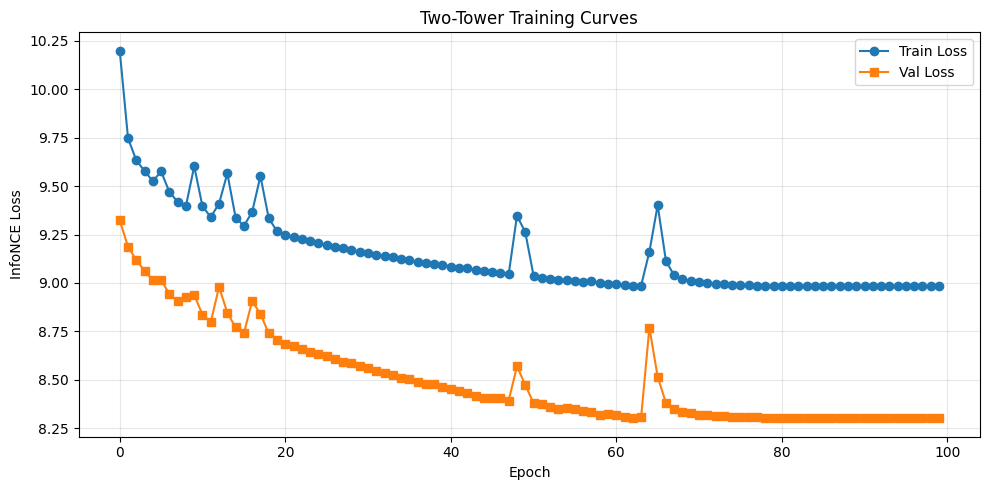

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses, label="Val Loss", marker="s")
plt.xlabel("Epoch")
plt.ylabel("InfoNCE Loss")
plt.title("Two-Tower Training Curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluation - Ranking Metrics

In [75]:
# Load best model
model.load_state_dict(torch.load(f"{DATA_DIR}/two_tower_best.pt"))
model.eval()
print("Loaded best model for evaluation")

Loaded best model for evaluation


In [76]:
# Precompute all item embeddings
print("Precomputing item embeddings...")
all_business_ids = list(business_features_dict.keys())
all_business_feats = np.stack([business_features_dict[bid] for bid in all_business_ids])
all_business_feats_tensor = torch.tensor(all_business_feats, dtype=torch.float32).to(device)

with torch.no_grad():
    batch_size = 2048
    all_item_embeddings = []
    for i in range(0, len(all_business_feats_tensor), batch_size):
        batch = all_business_feats_tensor[i:i+batch_size]
        item_emb = model.encode_item(batch)
        all_item_embeddings.append(item_emb.cpu())
    all_item_embeddings = torch.cat(all_item_embeddings, dim=0)

business_id_to_idx = {bid: idx for idx, bid in enumerate(all_business_ids)}
print(f"Precomputed {all_item_embeddings.shape[0]:,} item embeddings")

Precomputing item embeddings...
Precomputed 44,582 item embeddings


In [77]:
# Build training interaction set per user
import collections

train_items_per_user = collections.defaultdict(set)
for _, row in train_reviews.iterrows():
    uid = row["user_id"]
    bid = row["business_id"]
    if bid in business_id_to_idx:
        train_items_per_user[uid].add(business_id_to_idx[bid])

print(f"Built training sets for {len(train_items_per_user):,} users")

Built training sets for 157,358 users


In [78]:
def evaluate_ranking(model, eval_df, all_item_emb, business_id_to_idx,
                     train_items_per_user, user_feat_dict, split_name, Ks=[5, 10, 20]):
    """Leave-one-out ranking evaluation."""
    model.eval()

    eval_data = eval_df[
        (eval_df["label"] == 1) &
        eval_df["user_id"].isin(user_feat_dict) &
        eval_df["business_id"].isin(business_id_to_idx)
    ].reset_index(drop=True)

    n_skipped = len(eval_df) - len(eval_data)
    print(f"{split_name}: {len(eval_data):,} evaluable samples ({n_skipped:,} skipped)")

    all_ranks = []

    with torch.no_grad():
        batch_size = 512
        for start in tqdm(range(0, len(eval_data), batch_size), desc=f"Evaluating {split_name}"):
            end = min(start + batch_size, len(eval_data))
            batch_df = eval_data.iloc[start:end]

            user_feats = np.stack([user_feat_dict[uid] for uid in batch_df["user_id"]])
            user_feats_tensor = torch.tensor(user_feats, dtype=torch.float32).to(device)
            user_emb = model.encode_user(user_feats_tensor).cpu()

            scores = torch.matmul(user_emb, all_item_emb.T).numpy()

            for i, (_, row) in enumerate(batch_df.iterrows()):
                uid = row["user_id"]
                target_bid = row["business_id"]
                target_idx = business_id_to_idx[target_bid]

                seen = list(train_items_per_user[uid] - {target_idx})
                if seen:
                    scores[i, seen] = -np.inf

                target_score = scores[i, target_idx]
                rank = (scores[i] > target_score).sum() + 1
                all_ranks.append(rank)

    all_ranks = np.array(all_ranks)

    results = {}
    for k in Ks:
        hits = (all_ranks <= k).astype(float)
        results[k] = {
            "Hit@K": hits.mean(),
            "NDCG@K": np.where(all_ranks <= k, 1.0 / np.log2(all_ranks + 1), 0.0).mean(),
            "Precision@K": np.where(all_ranks <= k, 1.0 / k, 0.0).mean(),
            "Recall@K": hits.mean()
        }

    rows = [{"K": k, **results[k]} for k in Ks]
    metrics_df = pd.DataFrame(rows).set_index("K")
    print(f"\n{split_name} Results:")
    print(metrics_df.round(4).to_string())

    return metrics_df

In [ ]:
## Sampled Evaluation (same protocol as SVD baseline for fair comparison)
# 1 positive vs 99 randomly sampled negatives — matches 03_svd_baseline.ipynb exactly.

def evaluate_sampled(model, eval_df, train_df, user_feat_dict, business_feat_dict,
                     device, n_negatives=99, ks=[5, 10, 20], split_name="Val"):
    all_bids = list(business_feat_dict.keys())
    user_train_items = train_df.groupby("user_id")["business_id"].apply(set).to_dict()
    results = {k: {"precision": [], "recall": [], "ndcg": []} for k in ks}

    pos_rows = eval_df[
        (eval_df["label"] == 1) &
        eval_df["user_id"].isin(user_feat_dict) &
        eval_df["business_id"].isin(business_feat_dict)
    ].reset_index(drop=True)

    model.eval()
    rng = np.random.default_rng(42)

    with torch.no_grad():
        for _, row in tqdm(pos_rows.iterrows(), total=len(pos_rows),
                           desc=f"Sampled eval [{split_name}]"):
            uid, pos_bid = row["user_id"], row["business_id"]
            seen = user_train_items.get(uid, set())

            pool = [b for b in rng.choice(all_bids, n_negatives * 3, replace=False)
                    if b not in seen and b != pos_bid]
            negs = pool[:n_negatives]
            if len(negs) < n_negatives:
                continue  # skip if not enough negatives (rare edge case)

            candidates = [pos_bid] + negs  # positive is always index 0

            item_feats = torch.tensor(
                np.stack([business_feat_dict[b] for b in candidates]),
                dtype=torch.float32
            ).to(device)
            user_feat = torch.tensor(
                user_feat_dict[uid][None], dtype=torch.float32
            ).to(device)

            user_emb = model.encode_user(user_feat)          # (1, emb_dim)
            item_emb = model.encode_item(item_feats)         # (100, emb_dim)
            scores = (user_emb @ item_emb.T).squeeze(0).cpu().numpy()  # (100,)

            # rank of the positive (index 0) among all 100 candidates
            pos_rank = int((scores > scores[0]).sum()) + 1  # 1-indexed

            for k in ks:
                hit = pos_rank <= k
                results[k]["precision"].append(1.0 / k if hit else 0.0)
                results[k]["recall"].append(1.0 if hit else 0.0)
                results[k]["ndcg"].append(1.0 / np.log2(pos_rank + 1) if hit else 0.0)

    print(f"\n{split_name} Sampled Evaluation (1 pos + {n_negatives} neg):")
    for k in ks:
        p = np.mean(results[k]["precision"])
        r = np.mean(results[k]["recall"])
        n = np.mean(results[k]["ndcg"])
        print(f"k = {k} | Precision: {p:.4f} | Recall: {r:.4f} | NDCG: {n:.4f}")


In [79]:
# Full-catalogue ranking evaluation (hard task: rank 1 positive among all ~44k items)
val_metrics = evaluate_ranking(
    model, val_reviews, all_item_embeddings, business_id_to_idx,
    train_items_per_user, user_features_dict, "Validation"
)

test_metrics = evaluate_ranking(
    model, test_reviews, all_item_embeddings, business_id_to_idx,
    train_items_per_user, user_features_dict, "Test"
)

# Sampled evaluation — same protocol as SVD baseline for direct comparison
evaluate_sampled(model, val_reviews, train_reviews,
                 user_features_dict, business_features_dict, device, split_name="Validation")
evaluate_sampled(model, test_reviews, train_reviews,
                 user_features_dict, business_features_dict, device, split_name="Test")


## Comparison with SVD Baseline

In [80]:
# Load SVD baseline results if available
results_dir = f"{DATA_DIR}/results"
os.makedirs(results_dir, exist_ok=True)

try:
    svd_val = pd.read_csv(f"{results_dir}/svd_val_metrics_k100.csv", index_col="K")
    svd_test = pd.read_csv(f"{results_dir}/svd_test_metrics_k100.csv", index_col="K")

    print("\nComparison with SVD Baseline:")
    print("\nValidation Set:")
    comparison_val = pd.DataFrame({
        "SVD_NDCG@K": svd_val["NDCG@K"],
        "TwoTower_NDCG@K": val_metrics["NDCG@K"],
        "Improvement_%": ((val_metrics["NDCG@K"] - svd_val["NDCG@K"]) / svd_val["NDCG@K"] * 100).round(2)
    })
    print(comparison_val)

    print("\nTest Set:")
    comparison_test = pd.DataFrame({
        "SVD_NDCG@K": svd_test["NDCG@K"],
        "TwoTower_NDCG@K": test_metrics["NDCG@K"],
        "Improvement_%": ((test_metrics["NDCG@K"] - svd_test["NDCG@K"]) / svd_test["NDCG@K"] * 100).round(2)
    })
    print(comparison_test)

except FileNotFoundError:
    print("SVD baseline results not found. Run notebook 03 first.")


Comparison with SVD Baseline:

Validation Set:
    SVD_NDCG@K  TwoTower_NDCG@K  Improvement_%
K                                             
5     0.009790         0.046296         372.88
10    0.012672         0.056761         347.92
20    0.016049         0.067801         322.46

Test Set:
    SVD_NDCG@K  TwoTower_NDCG@K  Improvement_%
K                                             
5     0.008216         0.040256         390.01
10    0.010690         0.049840         366.23
20    0.013791         0.060135         336.03


## Save Results

In [73]:
# Save metrics
val_metrics.to_csv(f"{results_dir}/two_tower_val_metrics.csv")
test_metrics.to_csv(f"{results_dir}/two_tower_test_metrics.csv")

# Save training history
history_df = pd.DataFrame({
    "epoch": range(1, len(train_losses) + 1),
    "train_loss": train_losses,
    "val_loss": val_losses
})
history_df.to_csv(f"{results_dir}/two_tower_training_history.csv", index=False)

print(f"Saved results to {results_dir}/")
print("  - two_tower_val_metrics.csv")
print("  - two_tower_test_metrics.csv")
print("  - two_tower_training_history.csv")
print("  - two_tower_best.pt (model weights)")

Saved results to /content/drive/My Drive/rec_system/results/
  - two_tower_val_metrics.csv
  - two_tower_test_metrics.csv
  - two_tower_training_history.csv
  - two_tower_best.pt (model weights)


## Visualize Results

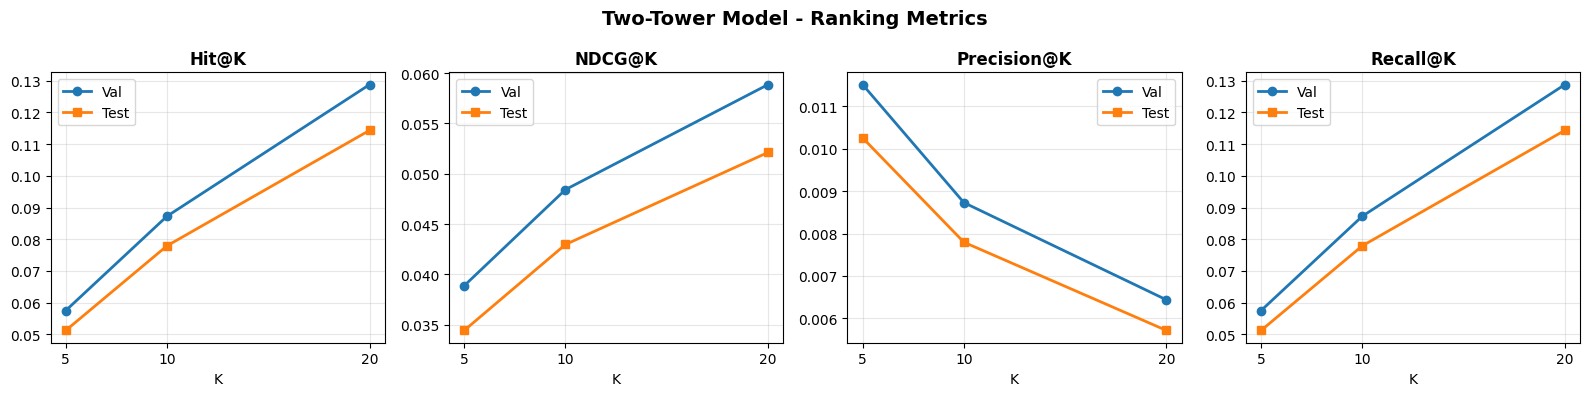

In [70]:
import matplotlib.pyplot as plt

Ks = [5, 10, 20]
metric_cols = ["Hit@K", "NDCG@K", "Precision@K", "Recall@K"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, metric_cols):
    ax.plot(val_metrics.index, val_metrics[col], marker="o", label="Val", linewidth=2)
    ax.plot(test_metrics.index, test_metrics[col], marker="s", label="Test", linewidth=2)
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel("K")
    ax.set_xticks(Ks)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Two-Tower Model - Ranking Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()